<a href="https://colab.research.google.com/github/seojun779/web_2026_bigdatacomputing/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  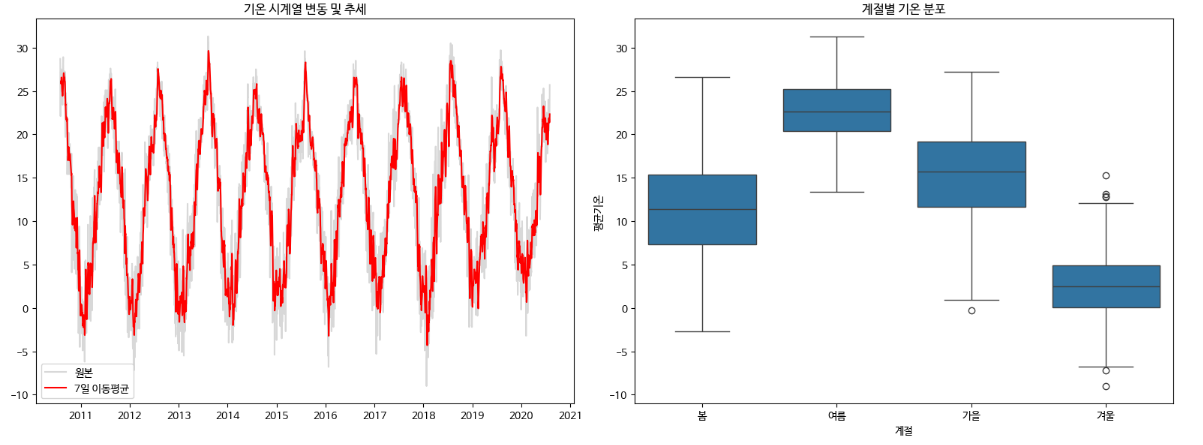

  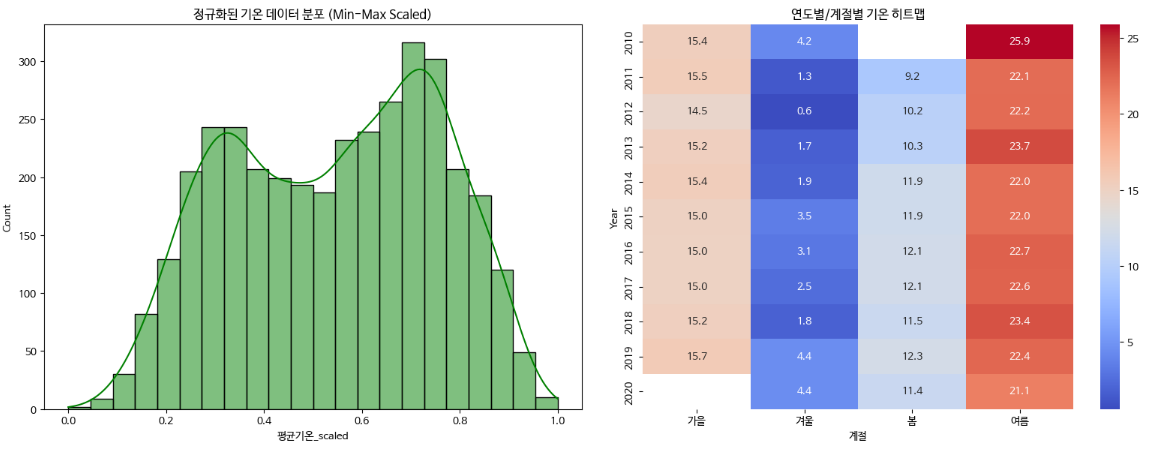



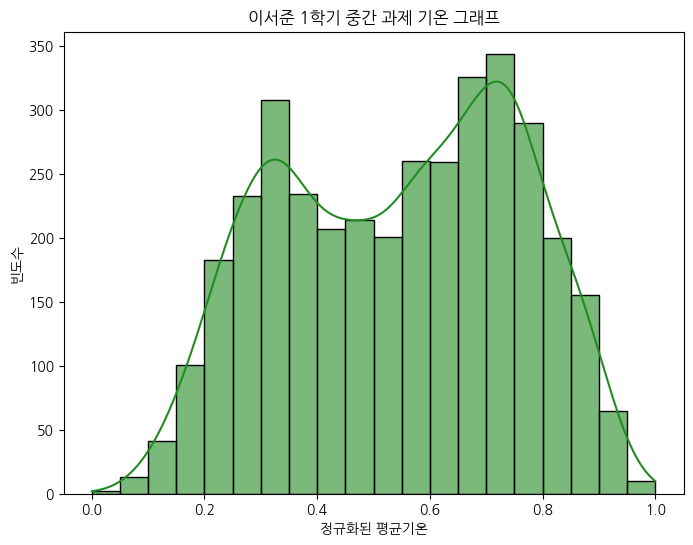

weather_analysis_report.xlsx 저장 완료


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import urllib.request
import os


# 한글 폰트 설정
def set_korean_font():
    font_path = "NanumGothic.ttf"

    if not os.path.exists(font_path):
        font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
        urllib.request.urlretrieve(font_url, font_path)

    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()

    plt.rc("font", family=font_name)
    plt.rcParams["axes.unicode_minus"] = False


# 데이터 불러오기
def load_data(url):
    weather = pd.read_csv(url, encoding="cp949")
    weather.columns = weather.columns.str.strip()
    return weather


# 데이터 전처리
def preprocess_data(weather):
    weather = weather[["일시", "평균기온", "최대풍속", "평균풍속"]]
    weather["일시"] = pd.to_datetime(weather["일시"])
    weather.dropna(inplace=True)
    return weather


# Min-Max 정규화
def min_max_scale(weather, column):
    min_value = weather[column].min()
    max_value = weather[column].max()

    weather[f"{column}_scaled"] = (
        weather[column] - min_value
    ) / (max_value - min_value)

    return weather


# 시계열 처리 및 이동평균
def time_series_analysis(weather):
    weather = weather.sort_values("일시")
    weather.set_index("일시", inplace=True)

    weather["7일_이동평균"] = weather["평균기온"].rolling(window=7).mean()
    return weather


# 계절 및 연도 컬럼 추가
def add_date_features(weather):
    def season(month):
        if month in [3, 4, 5]:
            return "봄"
        elif month in [6, 7, 8]:
            return "여름"
        elif month in [9, 10, 11]:
            return "가을"
        else:
            return "겨울"

    weather["계절"] = weather.index.month.map(season)
    weather["연도"] = weather.index.year

    return weather


# 계절별 통계
def get_season_statistics(weather):
    season_stat = weather.groupby("계절")[
        ["평균기온", "최대풍속", "평균풍속"]
    ].mean()

    return season_stat


# 연도별 Pivot Table
def create_pivot_table(weather):
    pivot = pd.pivot_table(
        weather,
        values="평균기온",
        index="연도",
        columns="계절",
        aggfunc="mean"
    )
    return pivot


# 히스토그램 그래프
def plot_temperature_distribution(weather):
    plt.figure(figsize=(8, 6))

    sns.histplot(
        weather["평균기온_scaled"],
        bins=20,
        kde=True,
        color="forestgreen",
        alpha=0.6
    )

    plt.title("이서준 1학기 중간 과제 기온 그래프")
    plt.xlabel("정규화된 평균기온")
    plt.ylabel("빈도수")
    plt.show()


# 엑셀 저장
def save_excel(weather, season_stat, pivot):
    with pd.ExcelWriter("weather_analysis_report.xlsx") as writer:
        weather.to_excel(writer, sheet_name="전처리데이터")
        season_stat.to_excel(writer, sheet_name="계절별통계")
        pivot.to_excel(writer, sheet_name="연도별피벗테이블")


# 메인 함수
def main():
    set_korean_font()

    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

    weather = load_data(url)
    weather = preprocess_data(weather)
    weather = min_max_scale(weather, "평균기온")
    weather = time_series_analysis(weather)
    weather = add_date_features(weather)

    season_stat = get_season_statistics(weather)
    pivot = create_pivot_table(weather)

    plot_temperature_distribution(weather)
    save_excel(weather, season_stat, pivot)

    print("weather_analysis_report.xlsx 저장 완료")


if __name__ == "__main__":
    main()